Handling Missing Values:

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
df_clean = df.copy()
df_clean = df_clean.dropna(subset=['user_id', 'date'])
num_cols = ['weight', 'height', 'blood_glucose', 'physical_activity', 'sleep_hours', 'bmi', 'risk_score']
for col in num_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())
cat_cols = ['diet', 'medication_adherence', 'stress_level', 'hydration_level']
for col in cat_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])
df_clean.isnull().sum()

,0
user_id,0
date,0
weight,0
height,0
blood_glucose,0
physical_activity,0
diet,0
medication_adherence,0
stress_level,0
sleep_hours,0


Outlier Detection (Boxplots):

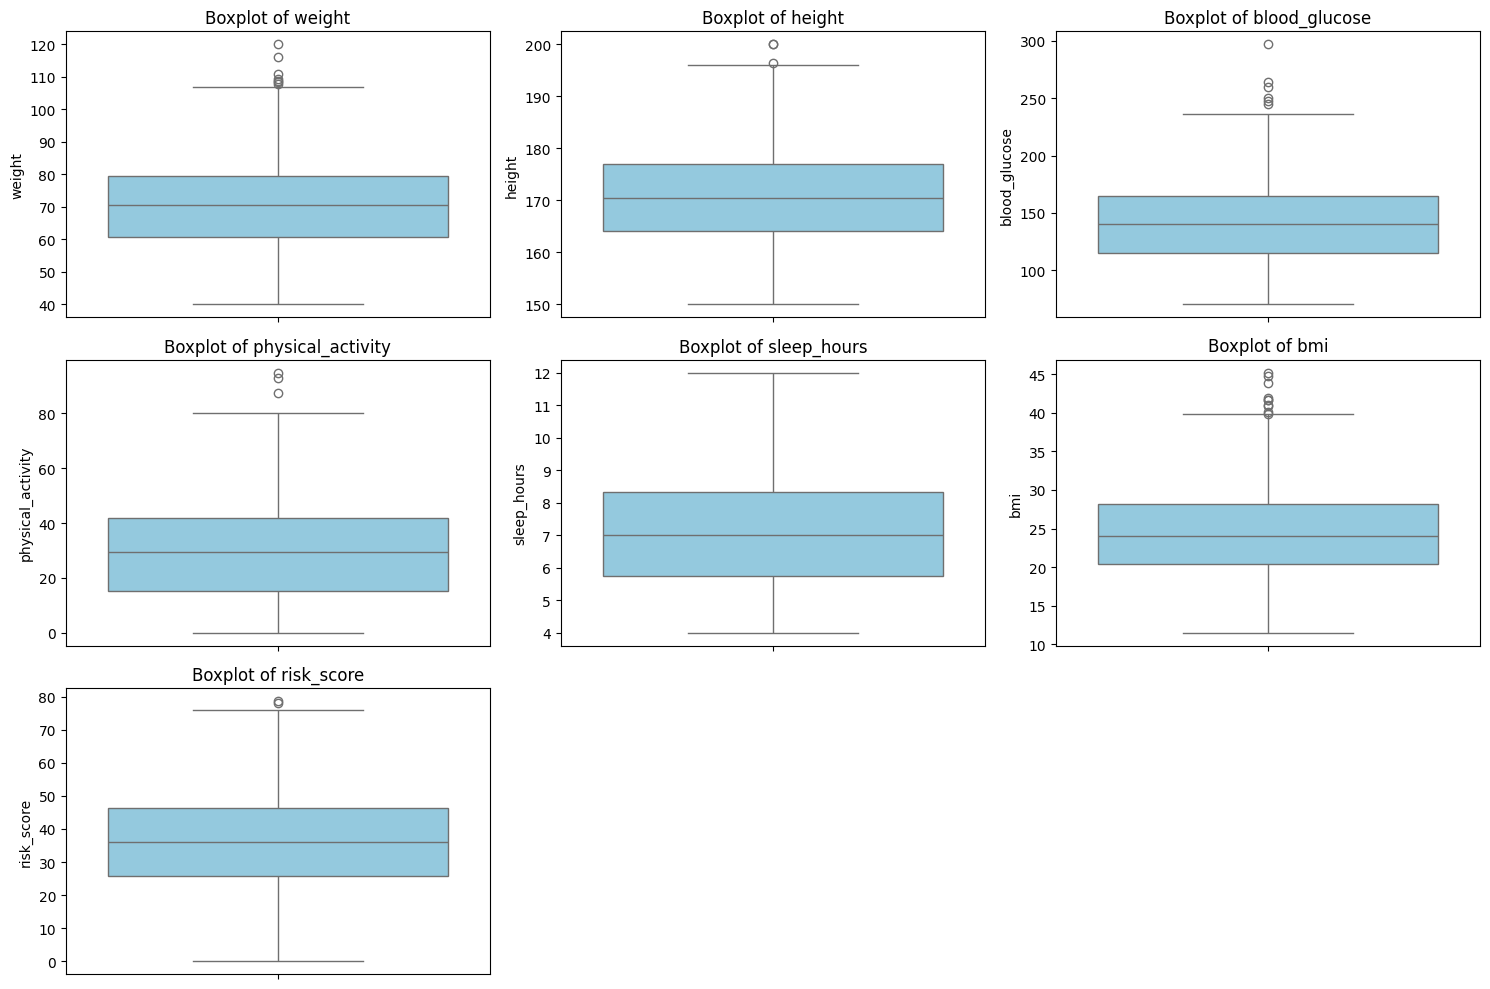

In [19]:
features = ['weight', 'height', 'blood_glucose', 'physical_activity', 'sleep_hours', 'bmi', 'risk_score']
plt.figure(figsize=(15, 10))
for i, col in enumerate(features, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df_clean[col], color='skyblue')
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

Outlier Detection (Z-score Method):

In [22]:
print("Outlier Detection (Z-score Method)")
z_scores = np.abs((df_clean[num_cols] - df_clean[num_cols].mean()) / df_clean[num_cols].std())
outliers = df_clean[(z_scores > 3).any(axis=1)]
print(f"Total outlier rows detected: {len(outliers)}")
print(outliers.head())

Outlier Detection (Z-score Method)
Total outlier rows detected: 13
     user_id        date      weight      height  blood_glucose  \
179    180.0  2021-07-16  110.802537  158.964107     140.271994   
209    210.0  2021-08-17  120.000000  187.495767     139.971656   
220    221.0  2021-08-29  104.719879  158.124016     125.666394   
241    242.0  2021-09-21   68.278953  167.964196     163.376519   
252    253.0  2021-10-03  101.832343  150.062644      81.952972   

     physical_activity  diet  medication_adherence  stress_level  sleep_hours  \
179          40.312562   1.0                   0.0           0.0     9.223397   
209          39.024506   1.0                   1.0           2.0     7.138736   
220           8.997185   0.0                   1.0           2.0     7.322084   
241          87.368061   1.0                   0.0           2.0     5.970297   
252          42.773203   0.0                   0.0           2.0    10.663110   

     hydration_level   bmi  risk_score  
17